In [1]:
import torch
import numpy as np
import pandas as pd
import joblib
from cnn_model import SDN_CNN  #SDN_CNN is out func name from cnn
from sklearn.model_selection import train_test_split
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score


In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
#load window data
X = np.load("X.npy")
y = np.load("y.npy")
timestamps = np.load("window_timestamps.npy")
switch_ids = np.load("window_switch_ids.npy")

print("X:", X.shape)
print("y:", y.shape)
print("timestamps:", timestamps.shape)
print("switch_ids:", switch_ids.shape)

X: (247830, 2, 9)
y: (247830,)
timestamps: (247830,)
switch_ids: (247830,)


In [3]:
#use same scaler as cnn for transformer as well
scaler = joblib.load("scaler.pkl")

# X shape: (samples, 2, 20)

# flatten time dimension
X_flat = X.reshape(-1, X.shape[2])   # (samples*2, 20)

# scale
X_scaled = scaler.transform(X_flat)

# restore original shape
X_scaled = X_scaled.reshape(X.shape)


In [4]:
#load cnn for the output an dinput to transformer

num_features = X_scaled.shape[1]
num_classes = len(np.unique(y))

cnn = SDN_CNN(num_features, num_classes).to(device)
cnn.load_state_dict(torch.load("cnn_model.pth")) #cnn model saved name 
cnn.eval()


for param in cnn.parameters():
    param.requires_grad = False

In [5]:
X_tensor = torch.tensor(X_scaled, dtype=torch.float32).to(device)

all_embeddings = []
all_labels = []

with torch.no_grad():
    for i in range(0, len(X_tensor), 512):
        batch = X_tensor[i:i+512]
        _, _, embeddings = cnn(batch)
        all_embeddings.append(embeddings.cpu())
        all_labels.extend(y[i:i+512])

all_embeddings = torch.cat(all_embeddings)
all_labels = np.array(all_labels)

print("Embeddings shape:", all_embeddings.shape)


Embeddings shape: torch.Size([247830, 128])


In [6]:
#building temporal sequence for each switch 

embedding_df = pd.DataFrame({
    "switch_id": switch_ids,
    "timestamp": timestamps,
    "label": y
})

embedding_df["embedding"] = list(all_embeddings)

embedding_df = embedding_df.sort_values(["switch_id", "timestamp"]).reset_index(drop=True)

print(embedding_df.head())

   switch_id     timestamp  label  \
0          1  1.771781e+09      0   
1          1  1.771781e+09      0   
2          1  1.771781e+09      0   
3          1  1.771781e+09      0   
4          1  1.771781e+09      0   

                                           embedding  
0  [tensor(-0.0367), tensor(0.1820), tensor(-0.01...  
1  [tensor(0.0067), tensor(0.1819), tensor(0.0284...  
2  [tensor(-0.0251), tensor(0.2884), tensor(0.079...  
3  [tensor(0.0765), tensor(0.1987), tensor(0.0871...  
4  [tensor(-0.1273), tensor(0.2484), tensor(-0.04...  


In [7]:
#transformer definition

In [8]:
class SDN_Transformer(nn.Module):
    def __init__(self, embedding_dim=128, num_classes=3):
        super().__init__()
        
        self.input_proj = nn.Linear(embedding_dim, 256)
        
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=256,
            nhead=8,
            dim_feedforward=512,
            dropout=0.1,
            batch_first=True
        )
        
        self.transformer = nn.TransformerEncoder(
            encoder_layer,
            num_layers=2
        )
        
        self.classifier = nn.Linear(256, num_classes)
        self.persistence_head = nn.Linear(256, 1)

    def forward(self, x):
        x = self.input_proj(x)
        x = self.transformer(x)
        
        x = x[:, -1, :]  # last token
        
        logits = self.classifier(x)
        persistence = self.persistence_head(x)
        
        return logits, persistence


In [9]:
# Sort by timestamp
embedding_df = embedding_df.sort_values("timestamp").reset_index(drop=True)

# Split index
cutoff_index = int(len(embedding_df) * 0.8)

train_df = embedding_df.iloc[:cutoff_index]
test_df  = embedding_df.iloc[cutoff_index:]


In [10]:
#creating a 10 step sequence per switch

SEQUENCE_LENGTH = 10

X_seq = []
y_seq = []

# grouped = embedding_df.groupby("switch_id")

# for switch_id, group in grouped:
    
#     group = group.reset_index(drop=True)
    
#     embeddings = np.stack(group["embedding"].values)
#     labels = group["label"].values
    
#     for i in range(len(group) - SEQUENCE_LENGTH + 1):
        
#         seq = embeddings[i:i+SEQUENCE_LENGTH]
#         label = labels[i+SEQUENCE_LENGTH-1]
        
#         X_seq.append(seq)
#         y_seq.append(label)

# X_seq = np.array(X_seq)
# y_seq = np.array(y_seq)

# print("Transformer input shape:", X_seq.shape)


def build_sequences(df):
    # X_seq = []
    # y_seq = []
    
    grouped = df.groupby("switch_id")
    
    for switch_id, group in grouped:
        group = group.sort_values("timestamp").reset_index(drop=True)
        
        embeddings = np.stack(group["embedding"].values)
        labels = group["label"].values
        
        for i in range(len(group) - SEQUENCE_LENGTH + 1):
            seq = embeddings[i:i+SEQUENCE_LENGTH]
            label = labels[i+SEQUENCE_LENGTH-1]
            
            X_seq.append(seq)
            y_seq.append(label)
    
    return np.array(X_seq), np.array(y_seq)

X_train, y_train = build_sequences(train_df)
X_test, y_test   = build_sequences(test_df)



In [11]:
def split_per_switch(df, split_ratio=0.8):
    train_parts = []
    test_parts = []

    grouped = df.groupby("switch_id")

    for switch_id, group in grouped:
        group = group.sort_values("timestamp").reset_index(drop=True)
        
        cutoff = int(len(group) * split_ratio)
        
        train_parts.append(group.iloc[:cutoff])
        test_parts.append(group.iloc[cutoff:])
    
    train_df = pd.concat(train_parts)
    test_df = pd.concat(test_parts)
    
    return train_df, test_df


In [12]:
#check for errors here
print(X_seq.shape)
print(y_seq.shape)
#should be like below
# (samples, 10, 128)
# (samples,)


AttributeError: 'list' object has no attribute 'shape'

In [13]:
#converting window to tensors now 

X_train_tensor = torch.tensor(X_train, dtype=torch.float32).to(device)
X_test_tensor  = torch.tensor(X_test, dtype=torch.float32).to(device)

y_train_tensor = torch.tensor(y_train, dtype=torch.long).to(device)
y_test_tensor  = torch.tensor(y_test, dtype=torch.long).to(device)


In [14]:
#data loader for transformer
batch_size = 128

train_loader = DataLoader(
    TensorDataset(X_train_tensor, y_train_tensor),
    batch_size=batch_size,
    shuffle=True
)

test_loader = DataLoader(
    TensorDataset(X_test_tensor, y_test_tensor),
    batch_size=batch_size,
    shuffle=False
)


In [15]:
#loading transformer now 
num_classes = len(np.unique(y_seq))

transformer = SDN_Transformer(
    embedding_dim=128,
    num_classes=num_classes
).to(device)


In [16]:
#adding class weights

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)

class_weights = torch.tensor(class_weights, dtype=torch.float32).to(device)

criterion = torch.nn.CrossEntropyLoss(weight=class_weights)

optimizer = torch.optim.Adam(transformer.parameters(), lr=0.0005)


In [17]:
#training loop now 

epochs = 15

for epoch in range(epochs):
    
    transformer.train()
    total_loss = 0
    
    for inputs, labels in train_loader:
        
        optimizer.zero_grad()
        
        logits, persistence = transformer(inputs)
        
        loss = criterion(logits, labels)
        
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
    
    # Evaluation
    transformer.eval()
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for inputs, labels in test_loader:
            logits, _ = transformer(inputs)
            preds = torch.argmax(logits, dim=1)
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    acc = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average="macro")
    prec = precision_score(all_labels, all_preds, average="macro")
    rec = recall_score(all_labels, all_preds, average="macro")
    
    print(
        f"Epoch [{epoch+1:02d}/{epochs}] | "
        f"Loss: {total_loss/len(train_loader):.4f} | "
        f"Acc: {acc:.4f} | "
        f"Prec: {prec:.4f} | "
        f"Rec: {rec:.4f} | "
        f"F1: {f1:.4f}"
    )


Epoch [01/15] | Loss: 0.2857 | Acc: 0.8996 | Prec: 0.7176 | Rec: 0.8760 | F1: 0.7116
Epoch [02/15] | Loss: 0.2644 | Acc: 0.9181 | Prec: 0.7315 | Rec: 0.8708 | F1: 0.7318
Epoch [03/15] | Loss: 0.2647 | Acc: 0.9158 | Prec: 0.7268 | Rec: 0.8752 | F1: 0.7335
Epoch [04/15] | Loss: 0.2609 | Acc: 0.9146 | Prec: 0.7288 | Rec: 0.8825 | F1: 0.7325
Epoch [05/15] | Loss: 0.2522 | Acc: 0.9238 | Prec: 0.7366 | Rec: 0.8759 | F1: 0.7411
Epoch [06/15] | Loss: 0.2607 | Acc: 0.9056 | Prec: 0.7219 | Rec: 0.8798 | F1: 0.7203
Epoch [07/15] | Loss: 0.2467 | Acc: 0.9179 | Prec: 0.7312 | Rec: 0.8887 | F1: 0.7407
Epoch [08/15] | Loss: 0.2435 | Acc: 0.9178 | Prec: 0.7343 | Rec: 0.8893 | F1: 0.7373
Epoch [09/15] | Loss: 0.2417 | Acc: 0.9156 | Prec: 0.7301 | Rec: 0.8806 | F1: 0.7332
Epoch [10/15] | Loss: 0.2515 | Acc: 0.9021 | Prec: 0.7194 | Rec: 0.8699 | F1: 0.7130
Epoch [11/15] | Loss: 0.2595 | Acc: 0.9200 | Prec: 0.7341 | Rec: 0.8922 | F1: 0.7442
Epoch [12/15] | Loss: 0.2400 | Acc: 0.9064 | Prec: 0.7259 | Rec: 

In [ ]:
print(train_df["label"].value_counts())
print(test_df["label"].value_counts())


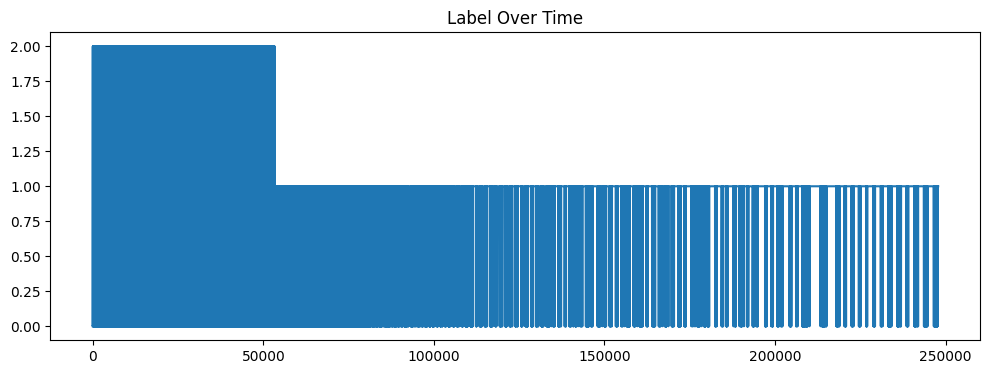

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))
plt.plot(embedding_df["label"].values)
plt.title("Label Over Time")
plt.show()

